What is Feature Selection?
Feature selection is the process of identifying and selecting a subset of the most relevant features (input variables) to include in a model. This technique improves model performance by removing irrelevant or redundant features, reducing overfitting, and enhancing generalization. The goal is to develop models using only the data required to make accurate predictions, favoring simpler, well-performing models.

#Why Feature Selection?

**Improves Model Performance:** By focusing on the most relevant features, models become more accurate in predicting new, unseen data.
Reduces Computational Complexity: Fewer features mean faster training and inference times, which is crucial for real-time or large-scale applications.

**Enhances Interpretability:** Simplifying models by removing noise makes it easier to understand how predictions are made, which is vital in sectors like healthcare and finance.


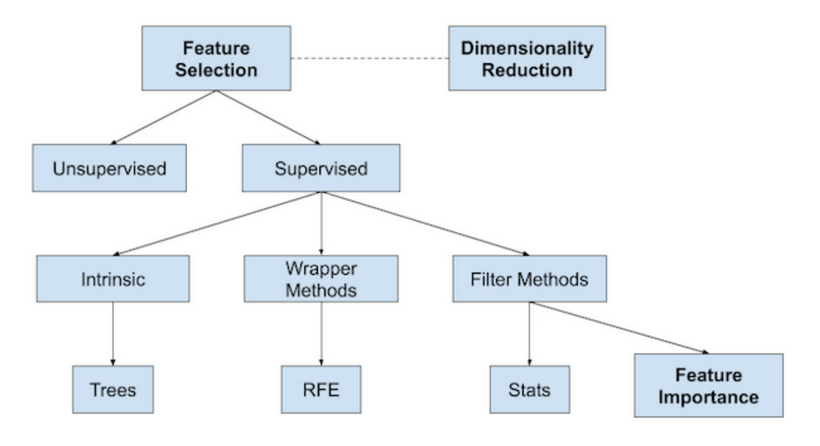

#Supervised Feature Selection

Supervised feature selection methods use the target variable to guide the selection of the most relevant features. Let’s dive into three popular categories: Filter, Wrapper, and Embedded methods.

First, lets load the iris dataset which we will be using throughout the article.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

#1. Filter Methods
Filter methods rely on statistical measures to evaluate the importance of features independently of the model. They are generally fast and easy to implement.

#1.1 Chi-Square Test

The Chi-Square test is used to measure the association between categorical features and the target variable. It works well when the target variable is also categorical.

When to use: Use the Chi-Square test when both the feature and the target variable are categorical.

Right now for the sake of understanding we are taking the dataset as it is.

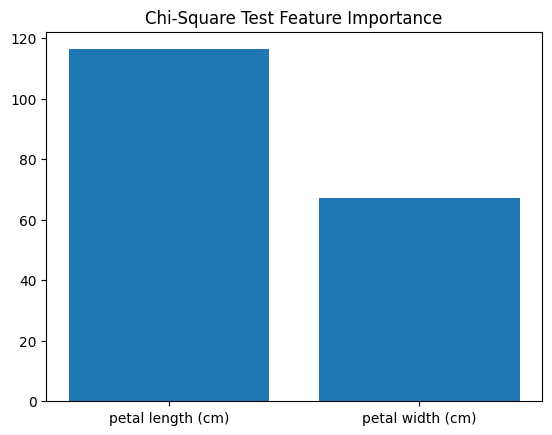

In [ ]:
# Apply Chi-Square test
chi2_selector = SelectKBest(chi2, k=2)
X_kbest = chi2_selector.fit_transform(X, y)

# Visualize selected features
selected_features = X.columns[chi2_selector.get_support()]
plt.bar(selected_features, chi2_selector.scores_[chi2_selector.get_support()])
plt.title('Chi-Square Test Feature Importance')

plt.show()

Explanation of the Graph: The bar chart shows the Chi-Square scores for the selected features. Higher scores indicate a stronger association between the feature and the target variable. In this example, we see which features are most important in distinguishing between the classes in the Iris dataset.

#1.2 ANOVA (Analysis of Variance)

ANOVA measures the variance between different groups and compares it to the variance within groups. It is used to identify whether there are any statistically significant differences between the means of different features concerning the target variable.

When to use: Use ANOVA when the target variable is categorical, and the features are numerical.

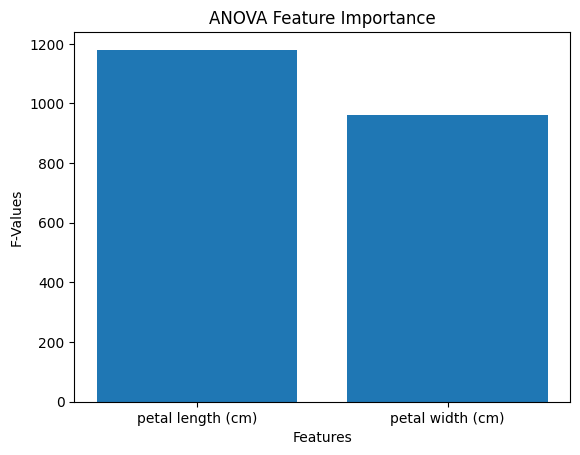

In [3]:
from sklearn.feature_selection import f_classif

# Apply ANOVA
anova_selector = SelectKBest(f_classif, k=2)
X_kbest_anova = anova_selector.fit_transform(X, y)

# Visualize selected features
selected_features_anova = X.columns[anova_selector.get_support()]
plt.bar(selected_features_anova, anova_selector.scores_[anova_selector.get_support()])
plt.title('ANOVA Feature Importance')
plt.xlabel('Features')
plt.ylabel('F-Values')
plt.show()

Explanation of the Graph: The bar chart displays the F-values for the selected features, showing the features with the most significant variance with respect to the target variable. Higher F-values indicate that the feature contributes more to the classification task.

#1.3 Correlation Coefficient

Correlation coefficients measure the linear relationship between features and the target variable. The Pearson correlation coefficient is commonly used to evaluate continuous variables.

When to use: Use the correlation coefficient when both the feature and target variable are continuous.

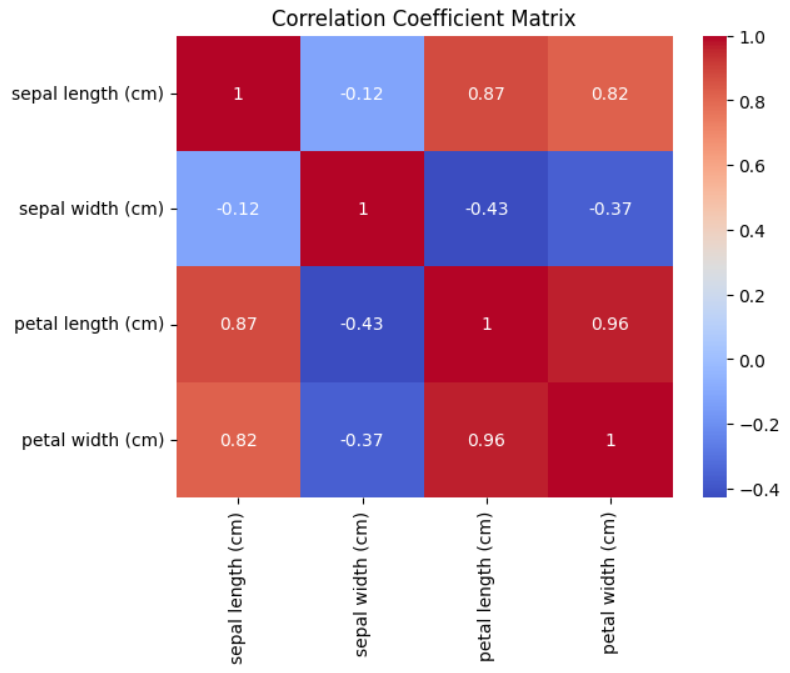

Explanation of the Graph: The heatmap displays the correlation coefficients between each pair of features. Values close to 1 or -1 indicate strong linear relationships, while values near 0 suggest weak or no linear relationship. This visualization helps identify highly correlated features that might be redundant.

#2. Wrapper Methods
Wrapper methods evaluate different combinations of features and select the best subset based on model performance. While these methods are computationally intensive, they often yield superior results.

#2.1 Recursive Feature Elimination (RFE)

RFE recursively removes the least important features and builds the model with the remaining features, iterating until the optimal subset is found.

When to use: Use RFE when model interpretability is essential, and you can afford the computational cost.

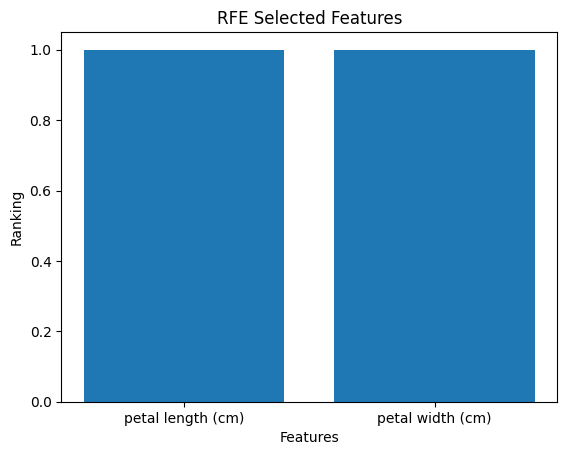

In [4]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Apply RFE
rfe_selector = RFE(estimator=RandomForestClassifier(), n_features_to_select=2)
X_rfe = rfe_selector.fit_transform(X, y)

# Visualize selected features
selected_features_rfe = X.columns[rfe_selector.get_support()]
plt.bar(selected_features_rfe, rfe_selector.ranking_[rfe_selector.get_support()])
plt.title('RFE Selected Features')
plt.xlabel('Features')
plt.ylabel('Ranking')
plt.show()

Explanation of the Graph: This bar chart illustrates the ranking of features after applying RFE. Features with lower rankings are more important, as RFE prioritizes them during selection. The graph highlights the most critical features for the model.

#2.2 Forward Selection

Forward selection starts with no features and adds them one by one, based on their contribution to improving the model’s performance.

When to use: Use Forward Selection when you need a simple and interpretable model, especially when dealing with a manageable number of features.

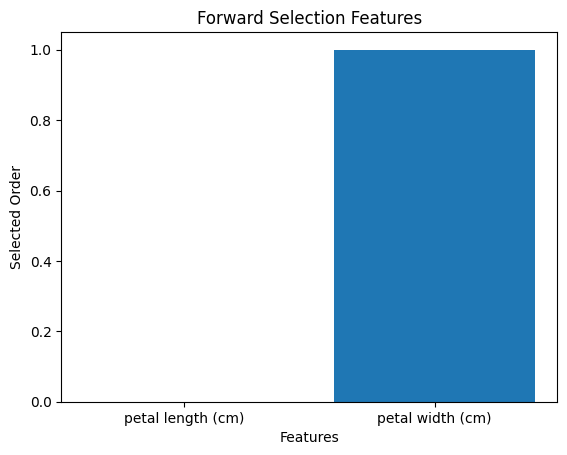

In [5]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.neighbors import KNeighborsClassifier

# Apply Forward Selection
sfs = SFS(KNeighborsClassifier(), k_features=2, forward=True, scoring='accuracy', cv=5)
sfs.fit(X, y)

# Visualize selected features
selected_features_fs = X.columns[list(sfs.k_feature_idx_)]
plt.bar(selected_features_fs, range(len(selected_features_fs)))
plt.title('Forward Selection Features')
plt.xlabel('Features')
plt.ylabel('Selected Order')
plt.show()

Explanation of the Graph: This bar chart shows the order in which features were selected during the Forward Selection process. The first features added have the highest impact on improving the model’s accuracy, as seen from their early selection.

#2.3 Backward Elimination

Backward elimination begins with all features and removes the least significant ones based on their p-values, refining the model iteratively.

When to use: Use Backward Elimination when you prefer a more gradual reduction of features, allowing for detailed examination of each feature’s impact.

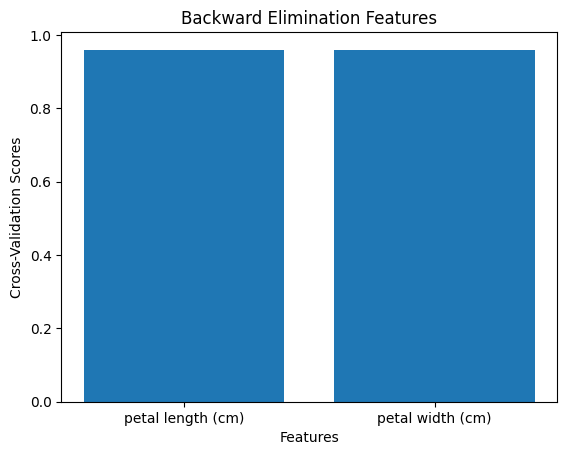

In [6]:
from sklearn.feature_selection import RFECV

# Apply Backward Elimination using RFECV
rfecv_selector = RFECV(estimator=RandomForestClassifier(), step=1, cv=5, scoring='accuracy')
X_rfecv = rfecv_selector.fit_transform(X, y)

# Visualize selected features
selected_features_rfecv = X.columns[rfecv_selector.get_support()]
plt.bar(selected_features_rfecv, rfecv_selector.cv_results_['mean_test_score'][rfecv_selector.get_support()])
plt.title('Backward Elimination Features')
plt.xlabel('Features')
plt.ylabel('Cross-Validation Scores')
plt.show()

Explanation of the Graph: The bar chart displays cross-validation scores for each feature selected by Backward Elimination. The features with higher scores contribute more to the model’s performance, indicating their importance in the final feature set.

#3. Embedded Methods
Embedded methods perform feature selection during the model training process. These methods are typically faster and offer a balance between performance and computation.

#3.1 Lasso Regression

Lasso Regression adds a penalty to the model for large coefficients, effectively shrinking some coefficients to zero, thereby performing feature selection.

When to use: Use Lasso Regression when you want to handle multicollinearity and perform feature selection simultaneously.

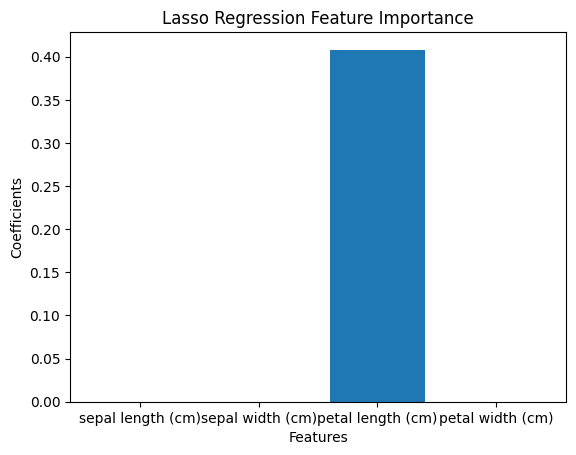

In [7]:
from sklearn.linear_model import Lasso

# Apply Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X, y)

# Visualize selected features
plt.bar(X.columns, lasso.coef_)
plt.title('Lasso Regression Feature Importance')
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.show()

Explanation of the Graph: The bar chart shows the coefficients assigned to each feature by Lasso Regression. Features with coefficients close to zero are less important and may be eliminated, highlighting the most influential features in the model.

#3.2 Tree-based Methods

Tree-based methods like Random Forests provide feature importance scores directly, which can be used to identify the most critical features.

When to use: Use Tree-based methods when you need a robust model that can handle both classification and regression tasks, and when interpretability is less of a concern.

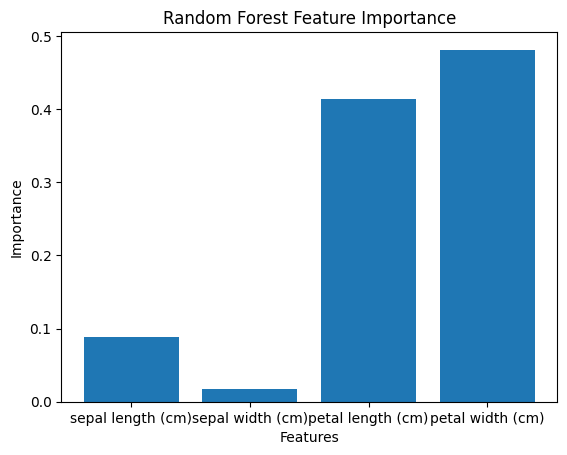

In [8]:
# Apply Random Forest
rf = RandomForestClassifier()
rf.fit(X, y)

# Visualize feature importance
plt.bar(X.columns, rf.feature_importances_)
plt.title('Random Forest Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()


Explanation of the Graph: This bar chart displays the importance scores assigned to each feature by the Random Forest model. Features with higher importance scores contribute more to the model’s predictions, helping to identify the most valuable features.

#Unsupervised Feature Selection

Unsupervised feature selection methods are used when there is no target variable available. These methods are often employed for dimensionality reduction.

#1. Principal Component Analysis (PCA)
PCA reduces the dimensionality of the data by transforming the features into a set of uncorrelated principal components, capturing as much variance as possible.

When to use: Use PCA when you want to reduce the number of features while retaining most of the variance in the data.

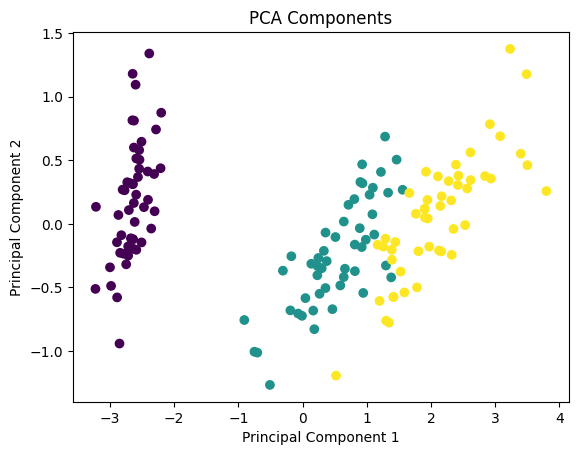

In [10]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualize PCA components
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Explanation of the Graph: The scatter plot visualizes the data in the reduced feature space created by PCA. The two principal components shown capture the maximum variance in the data, allowing us to see the separation between different classes in a lower-dimensional space.

#2. Independent Component Analysis (ICA)
ICA separates a multivariate signal into additive, independent components. It’s useful when the features are assumed to be mixtures of independent sources.

When to use: Use ICA when the features are non-Gaussian, and you believe they are mixed signals from different sources.

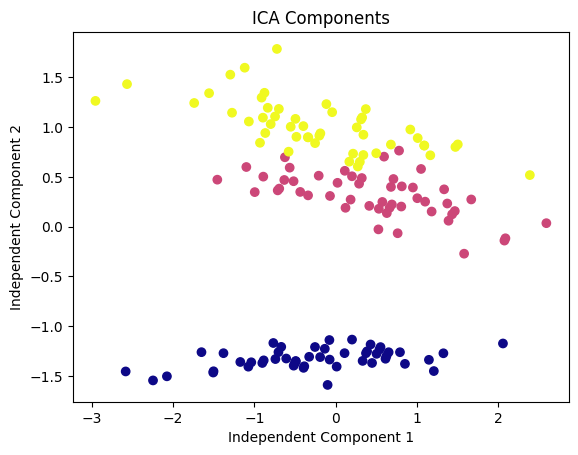

In [11]:
from sklearn.decomposition import FastICA

# Apply ICA
ica = FastICA(n_components=2)
X_ica = ica.fit_transform(X)

# Visualize ICA components
plt.scatter(X_ica[:, 0], X_ica[:, 1], c=y, cmap='plasma')
plt.title('ICA Components')
plt.xlabel('Independent Component 1')
plt.ylabel('Independent Component 2')
plt.show()

**Explanation of the Graph:** The scatter plot displays the data projected onto the independent components identified by ICA. This transformation helps in uncovering the underlying sources that contribute to the observed data, often revealing structure not apparent in the original feature space.

#Conclusion
Feature selection is an essential technique in machine learning, helping to improve model performance, reduce complexity, and enhance interpretability. In this article, we explored a variety of supervised and unsupervised feature selection methods using Python, including practical examples with the Iris dataset. Each method has its strengths and applications, and understanding when to use each can significantly impact your model’s success.

Whether you’re dealing with labeled or unlabeled data, the right feature selection approach can make all the difference in your analysis. Experiment with these techniques to find the best fit for your specific dataset and problem.